# disscube — Estudo de Caso Real: Ilha do Maranhão

## Contexto

Este notebook reproduz o pré-processamento de dados do estudo de caso
**BR-MANGUE** usando os arquivos reais em `data/raw/`.

Fontes utilizadas:

| Arquivo | Conteúdo | CRS | Res. |
|---------|----------|-----|------|
| `ilha_maranhao.tif` | 3 bandas: uso da terra, altitude, tipo de solo | EPSG:31983 (UTM 23S) | ~100 m |
| `ilha_maranhao_mapbiomas_2010.tif` | MapBiomas 2010 — legenda COL 8 | EPSG:4326 | ~30 m |
| `ilha_maranhao_mapbiomas_2022.tif` | MapBiomas 2022 — legenda COL 8 | EPSG:4326 | ~30 m |
| `urban_center/centros_urbanos_m_100…shp` | Centros urbanos (≥ 100 k hab.) — PNLT | EPSG:5880 | vetor |

A grade-alvo é **`ilha_maranhao/100m`** no sistema BDC Albers — o mesmo
sistema de referência das grades nacionais do Brazil Data Cube.

> **Pré-requisito**: os arquivos `data/raw/` precisam existir. O catálogo e
> o store são criados num diretório temporário a cada execução.


## Setup

In [1]:
%matplotlib inline
import os, pathlib, tempfile, warnings
warnings.filterwarnings("ignore")

import numpy as np
import rasterio
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches

from disscube import CubeClient, GridSpec, SpatialSource, SpatialDerivation, Variable
from disscube.utils.grids import register_local_grid

# ── Localizar a raiz do projeto ───────────────────────────────────────────────
# nbconvert executa com CWD = diretório do notebook; sobe dois níveis.
_cwd = pathlib.Path.cwd()
if (_cwd / "data" / "raw").exists():
    PROJECT_ROOT = _cwd
elif (_cwd.parent.parent / "data" / "raw").exists():
    PROJECT_ROOT = _cwd.parent.parent
else:
    raise FileNotFoundError(
        f"Não encontrei data/raw/ a partir de {_cwd}. "
        "Execute o notebook a partir da raiz do projeto disscube/."
    )
os.chdir(PROJECT_ROOT)
DATA_RAW = PROJECT_ROOT / "data" / "raw"
print(f"Raiz do projeto : {PROJECT_ROOT}")
print(f"Dados brutos    : {DATA_RAW}")

# ── Catálogo e store em tmpdir — re-executável ────────────────────────────────
tmpdir       = pathlib.Path(tempfile.mkdtemp(prefix="disscube_maranhao_"))
catalog_path = str(tmpdir / "catalog.db")
store_path   = str(tmpdir / "store")
cube         = CubeClient(catalog=catalog_path, store=store_path)
print(f"\nCatálogo: {catalog_path}")
print(f"Store   : {store_path}")


Raiz do projeto : /home/sergio/dev/github/dissmodel/disscube
Dados brutos    : /home/sergio/dev/github/dissmodel/disscube/data/raw



Catálogo: /tmp/disscube_maranhao_g0e_98b9/catalog.db
Store   : /tmp/disscube_maranhao_g0e_98b9/store


## Explorar os dados de entrada

Antes de registrar qualquer coisa no catálogo, é boa prática inspecionar
os metadados dos arquivos: CRS, resolução, extensão e tipo de dado.


In [2]:
ILHA_TIF  = str(DATA_RAW / "ilha_maranhao.tif")
MB_2010   = str(DATA_RAW / "ilha_maranhao_mapbiomas_2010.tif")
MB_2022   = str(DATA_RAW / "ilha_maranhao_mapbiomas_2022.tif")
URBAN_SHP = str(DATA_RAW / "urban_center" /
                "centros_urbanos_m_100_pnlt_poly_sirgas2000.shp")

# ── Metadados dos rasters ─────────────────────────────────────────────────────
print("Rasters:")
for label, path in [("ilha_maranhao", ILHA_TIF),
                    ("mapbiomas_2010", MB_2010),
                    ("mapbiomas_2022", MB_2022)]:
    with rasterio.open(path) as src:
        print(f"  [{label}]")
        print(f"    CRS      : {src.crs}")
        print(f"    Shape    : {src.height} × {src.width}  ({src.count} banda(s))")
        print(f"    Resolução: {src.res[0]:.4f} × {src.res[1]:.4f} unidades do CRS")
        print(f"    Bounds   : {src.bounds}")
        print(f"    dtype    : {src.dtypes}")
        print()

# ── Metadados do vetor ────────────────────────────────────────────────────────
urban = gpd.read_file(URBAN_SHP)
print(f"Centros urbanos:")
print(f"  CRS    : {urban.crs}")
print(f"  Feições: {len(urban)}")
print(f"  Bounds : {urban.total_bounds.round(0)}")


Rasters:
  [ilha_maranhao]
    CRS      : EPSG:31983
    Shape    : 418 × 405  (3 banda(s))
    Resolução: 99.8960 × 99.9739 unidades do CRS
    Bounds   : BoundingBox(left=568899.8382888247, bottom=9692870.241629517, right=609357.717581165, top=9734659.31170874)
    dtype    : ('int16', 'int16', 'int16')

  [mapbiomas_2010]
    CRS      : EPSG:4326
    Shape    : 1470 × 1452  (1 banda(s))
    Resolução: 0.0003 × 0.0003 unidades do CRS
    Bounds   : BoundingBox(left=-44.413785625210096, bottom=-2.799240256844839, right=-44.02247948744763, top=-2.40308321654813)
    dtype    : ('uint8',)

  [mapbiomas_2022]
    CRS      : EPSG:4326
    Shape    : 1470 × 1452  (1 banda(s))
    Resolução: 0.0003 × 0.0003 unidades do CRS
    Bounds   : BoundingBox(left=-44.413785625210096, bottom=-2.799240256844839, right=-44.02247948744763, top=-2.40308321654813)
    dtype    : ('uint8',)

Centros urbanos:
  CRS    : EPSG:5880
  Feições: 224
  Bounds : [ 3486204.  6452714.  7113416. 10313608.]


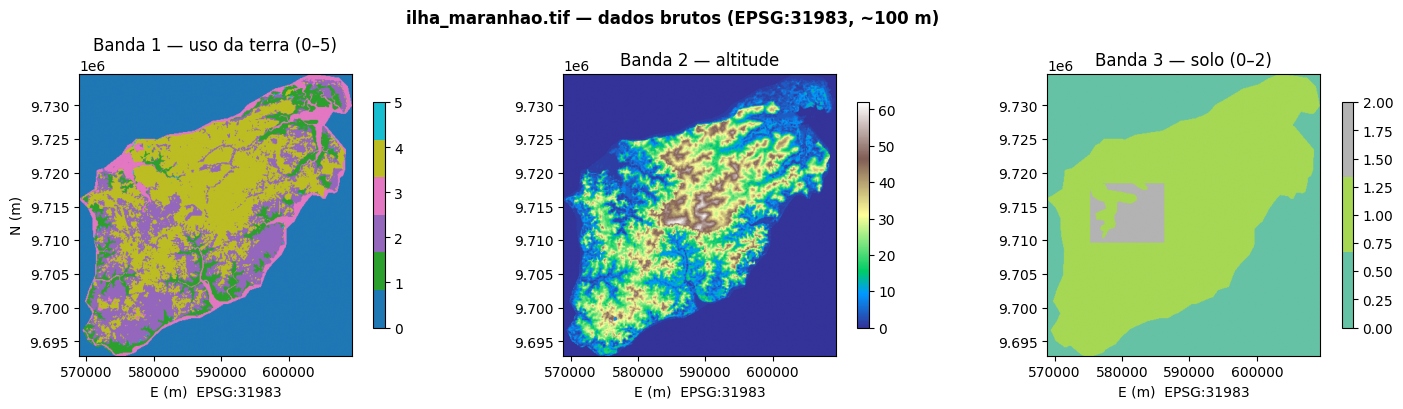

In [3]:
# ── Ler a imagem base (pequena, 0.1 MB) e plotar as 3 bandas ────────────────
with rasterio.open(ILHA_TIF) as src:
    ilha = src.read()           # (3, 418, 405)
    bounds_ilha = src.bounds
    crs_ilha    = src.crs

uso_raw  = ilha[0]  # band 1: classes de uso da terra (0-5)
alt_raw  = ilha[1]  # band 2: altitude em unidades relativas
solo_raw = ilha[2]  # band 3: tipo de solo (0-2)

ext = [bounds_ilha.left, bounds_ilha.right, bounds_ilha.bottom, bounds_ilha.top]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

cmap_uso  = plt.get_cmap("tab10", 6)
cmap_solo = plt.get_cmap("Set2",  3)

im0 = axes[0].imshow(uso_raw,  cmap=cmap_uso,  vmin=0, vmax=5,
                     origin="upper", extent=ext)
axes[0].set_title("Banda 1 — uso da terra (0–5)")
axes[0].set_xlabel("E (m)  EPSG:31983")
axes[0].set_ylabel("N (m)")
plt.colorbar(im0, ax=axes[0], ticks=range(6), shrink=0.8)

im1 = axes[1].imshow(alt_raw,  cmap="terrain", origin="upper", extent=ext)
axes[1].set_title("Banda 2 — altitude")
axes[1].set_xlabel("E (m)  EPSG:31983")
plt.colorbar(im1, ax=axes[1], shrink=0.8)

im2 = axes[2].imshow(solo_raw, cmap=cmap_solo, vmin=0, vmax=2,
                     origin="upper", extent=ext)
axes[2].set_title("Banda 3 — solo (0–2)")
axes[2].set_xlabel("E (m)  EPSG:31983")
plt.colorbar(im2, ax=axes[2], shrink=0.8)

plt.suptitle("ilha_maranhao.tif — dados brutos (EPSG:31983, ~100 m)",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()


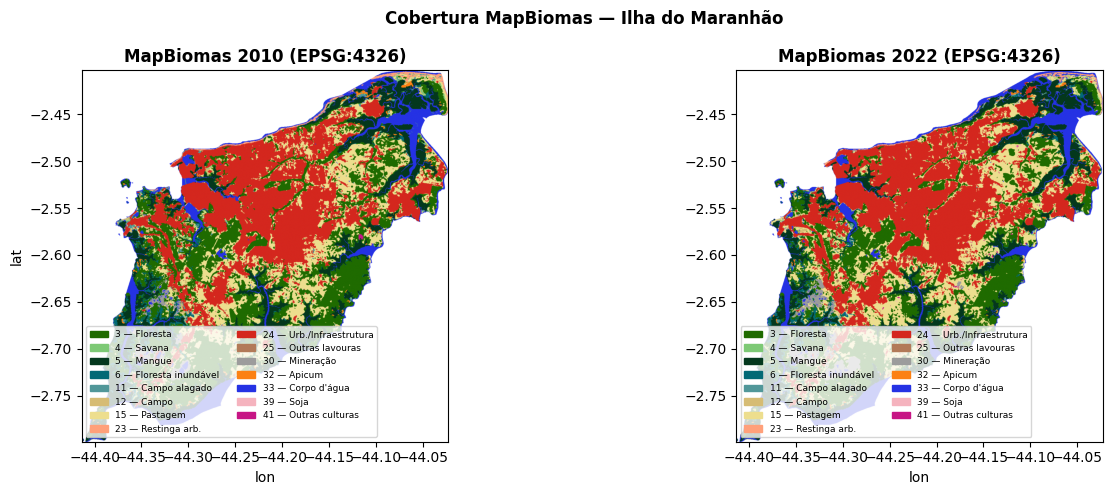

In [4]:
# ── MapBiomas: distribuição de classes (2010 vs 2022) ────────────────────────
MB_LEGEND = {
    0:  ("Sem dado",          "#ffffff"),
    3:  ("Floresta",          "#1f6b00"),
    4:  ("Savana",            "#7DC975"),
    5:  ("Mangue",            "#04381d"),
    6:  ("Floresta inundável","#026975"),
    11: ("Campo alagado",     "#519799"),
    12: ("Campo",             "#d6bc74"),
    15: ("Pastagem",          "#edde8e"),
    23: ("Restinga arb.",     "#ffa07a"),
    24: ("Urb./Infraestrutura","#d4271e"),
    25: ("Outras lavouras",   "#b27a58"),
    30: ("Mineração",         "#9c9c9c"),
    32: ("Apicum",            "#fc8114"),
    33: ("Corpo d'água",      "#2532e4"),
    39: ("Soja",              "#f5b3be"),
    41: ("Outras culturas",   "#c71585"),
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, path, year in [(axes[0], MB_2010, 2010), (axes[1], MB_2022, 2022)]:
    with rasterio.open(path) as src:
        data = src.read(1)
        ext_mb = [src.bounds.left, src.bounds.right,
                  src.bounds.bottom, src.bounds.top]

    classes = sorted(MB_LEGEND)
    cmap_mb = mcolors.ListedColormap([MB_LEGEND[c][1] for c in classes])
    bounds_mb = [c - 0.5 for c in classes] + [classes[-1] + 0.5]
    norm_mb = mcolors.BoundaryNorm(bounds_mb, len(classes))

    ax.imshow(data, cmap=cmap_mb, norm=norm_mb, origin="upper", extent=ext_mb)
    ax.set_title(f"MapBiomas {year} (EPSG:4326)", fontweight="bold")
    ax.set_xlabel("lon")
    if year == 2010:
        ax.set_ylabel("lat")

    patches = [mpatches.Patch(color=MB_LEGEND[c][1], label=f"{c} — {MB_LEGEND[c][0]}")
               for c in classes if c != 0]
    ax.legend(handles=patches, fontsize=6.5, loc="lower left", ncol=2)

plt.suptitle("Cobertura MapBiomas — Ilha do Maranhão", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()


## Registrar a grade-alvo (`register_local_grid`)

O disscube inclui o utilitário `register_local_grid()` para criar grades
locais alinhadas ao sistema nacional do Brazil Data Cube (BDC Albers).

O BDC Albers (Cônica de Albers Equivalente em Área para o Brasil) é o CRS
padrão dos produtos MapBiomas e dos projetos DisSModel. Usar este CRS garante
que os pixels da grade local se encaixam perfeitamente na malha nacional,
sem rasterização adicional ao alinhar produtos de diferentes fontes.

O argumento `snap=True` faz com que a bounding box seja arredondada para
múltiplos da resolução no sistema de referência alvo.


In [5]:
import logging
logging.basicConfig(level=logging.INFO, format="%(message)s")

# bbox geográfica da Ilha do Maranhão (lon_min, lat_min, lon_max, lat_max)
BBOX_GEO = (-44.42, -2.80, -44.02, -2.40)

grid = register_local_grid(
    cube,
    name       = "ilha_maranhao",
    bbox_geo   = BBOX_GEO,
    resolution = 100.0,
    snap       = True,
)

print(f"\nGrade registrada : {grid.id!r}")
print(f"  CRS            : {grid.crs[:60]}…")
print(f"  BBox (BDC)     : {[round(v) for v in grid.bbox]}")
print(f"  Dimensões      : {grid.rows} linhas × {grid.cols} colunas")
print(f"  Total de células: {grid.rows * grid.cols:,}")


[grid] registered 'ilha_maranhao/100m'  bbox(BDC Albers)=[6062500, 11008700, 6108500, 11054600]  bbox(geo)=lon[-44.42,-44.02] lat[-2.81,-2.39]  size=459×460 cells  (100 m pixels)



Grade registrada : 'ilha_maranhao/100m'
  CRS            : +proj=aea +lat_0=-12 +lon_0=-54 +lat_1=-2 +lat_2=-22 +x_0=50…
  BBox (BDC)     : [6062500, 11008700, 6108500, 11054600]
  Dimensões      : 459 linhas × 460 colunas
  Total de células: 211,140


## Registrar fontes (`SpatialSource`)

Registramos quatro fontes distintas:

1. **`maranhao_base`** — raster multi-banda (uso / alt / solo) já em ~100 m.
2. **`mapbiomas_2010`** e **`mapbiomas_2022`** — rasters MapBiomas em ~30 m,
   EPSG:4326. O campo `time` marca o ano da observação; o pipeline o
   propaga para o `DerivedVariable.times`, permitindo séries temporais.
3. **`centros_urbanos`** — camada vetorial de pontos (EPSG:5880).

> **Nota sobre `band_map`**: `maranhao_base` tem 3 bandas. Sem `band_map`,
> o pipeline associa variáveis às bandas por posição na lista de `Variable`.
> Com `band_map`, você nomeia explicitamente a associação — útil quando a
> ordem das variáveis na derivação não coincide com a ordem das bandas no arquivo.


In [6]:
# ── Fonte base (3 bandas, atribuição por posição) ─────────────────────────────
src_base = SpatialSource(
    id        = "maranhao_base",
    name      = "Ilha do Maranhão — uso/alt/solo (EPSG:31983)",
    format    = "raster",
    asset_url = ILHA_TIF,
    crs       = "EPSG:31983",
)
cube.register_spatial_source(src_base)

# ── MapBiomas temporal (source.time = ano da observação) ──────────────────────
for year, path in [(2010, MB_2010), (2022, MB_2022)]:
    src_mb = SpatialSource(
        id        = f"mapbiomas_ilha_ma_{year}",
        name      = f"MapBiomas Ilha do Maranhão — {year}",
        format    = "raster",
        asset_url = path,
        crs       = "EPSG:4326",
        time      = year,         # ano → DerivedVariable.times = [year]
    )
    cube.register_spatial_source(src_mb)

# ── Centros urbanos (vetor) ───────────────────────────────────────────────────
src_urban = SpatialSource(
    id        = "centros_urbanos",
    name      = "Centros urbanos ≥ 100 k hab. — PNLT (EPSG:5880)",
    format    = "vector",
    asset_url = URBAN_SHP,
    crs       = "EPSG:5880",
)
cube.register_spatial_source(src_urban)

print("Fontes registradas:")
for src in [src_base, src_urban]:
    print(f"  [{src.format:6s}] {src.id!r}")
print(f"  [raster] 'mapbiomas_ilha_ma_2010'")
print(f"  [raster] 'mapbiomas_ilha_ma_2022'")


Fontes registradas:
  [raster] 'maranhao_base'
  [vector] 'centros_urbanos'
  [raster] 'mapbiomas_ilha_ma_2010'
  [raster] 'mapbiomas_ilha_ma_2022'


## Derivar variáveis estáticas (múltiplas de uma vez)

Um único `SpatialDerivation` pode derivar várias variáveis de uma mesma fonte.
O pipeline lê e reprojecta o arquivo uma vez, depois aplica cada operador
sobre a banda correspondente — eficiente quando a fonte é multi-banda.

Aqui derivamos `uso`, `alt` e `solo` de `maranhao_base` num único `derive()`:
* **`uso`** — operator `majority`: classe dominante de uso da terra por célula.
  Usa alinhamento fino (lê pixels originais, não faz média de códigos de classe).
* **`alt`** — operator `mean`: altitude média dos pixels de origem na célula.
  O pipeline reprojecta via `Resampling.average` do rasterio (rápido).
* **`solo`** — operator `majority`: tipo de solo dominante por célula.

Como não há `band_map`, a associação é por posição:
`uso` → banda 1, `alt` → banda 2, `solo` → banda 3.


In [7]:
print("Derivando uso / alt / solo de maranhao_base…")
derived_static = cube.derive(SpatialDerivation(
    source_id = "maranhao_base",
    grid_id   = "ilha_maranhao/100m",
    role      = "driver",
    variables = [
        Variable(name="uso",  operator="majority"),
        Variable(name="alt",  operator="mean"),
        Variable(name="solo", operator="majority"),
    ],
))
print(f"Derivados: {[v.name for v in derived_static]}")
print(f"spec_hash : {derived_static[0].spec_hash[:16]}…  (mesmo para as 3 variáveis)")


Derivando uso / alt / solo de maranhao_base…


Derivados: ['uso', 'alt', 'solo']
spec_hash : 9623659920d03304…  (mesmo para as 3 variáveis)


## Série temporal MapBiomas

Variáveis temporais são derivadas como qualquer variável estática, mas
a `SpatialSource` carrega o campo `time` que é propagado para
`DerivedVariable.times`.

Ao chamar `cube.load("uso_mb")` mais tarde, o loader detecta que há
múltiplos `DerivedVariable` com `times` preenchidos e os concatena
automaticamente ao longo de um eixo `time`, retornando um
`xr.DataArray` com dimensões `(time, y, x)`.

O `spec_hash` inclui `source_id` e `valid_from`/`valid_until`, de modo que
derivações de anos diferentes têm hashes diferentes e coexistem no catálogo
sem conflito.


In [8]:
for year in [2010, 2022]:
    print(f"Derivando uso_mb para {year}…")
    derived_mb = cube.derive(SpatialDerivation(
        source_id = f"mapbiomas_ilha_ma_{year}",
        grid_id   = "ilha_maranhao/100m",
        role      = "land_use",
        variables = [Variable(name="uso_mb", operator="majority")],
    ))
    dv = derived_mb[0]
    print(f"  → name={dv.name!r}  times={dv.times}  spec_hash={dv.spec_hash[:12]}…")

print()
print("Carregando série temporal…")
da_mb = cube.load("uso_mb", grid_id="ilha_maranhao/100m")
print(f"DataArray temporal: dims={da_mb.dims}  shape={da_mb.shape}")
print(f"  time coords: {da_mb.coords['time'].values}")


Derivando uso_mb para 2010…


  → name='uso_mb'  times=[2010]  spec_hash=8b82474911f2…
Derivando uso_mb para 2022…


  → name='uso_mb'  times=[2022]  spec_hash=7e47ca91b354…

Carregando série temporal…
DataArray temporal: dims=('time', 'y', 'x')  shape=(2, 459, 460)
  time coords: [2010 2022]


## Distância a centros urbanos (`min_distance`)

O operador `min_distance` aceita **fontes vetoriais**: reprojecta o
`GeoDataFrame` para o CRS da grade, faz o clip na bbox, rasteriza as
geometrias e aplica `scipy.ndimage.distance_transform_edt`.

O resultado é a distância euclidiana (em metros, nas unidades do CRS da grade)
de cada célula ao centro urbano mais próximo — um driver clássico em modelos
de mudança de uso da terra.


In [9]:
print("Derivando dist_sedes (min_distance sobre centros urbanos)…")
derived_dist = cube.derive(SpatialDerivation(
    source_id = "centros_urbanos",
    grid_id   = "ilha_maranhao/100m",
    role      = "driver",
    variables = [Variable(name="dist_sedes", operator="min_distance")],
))
dv = derived_dist[0]
print(f"  → name={dv.name!r}  dtype={dv.dtype}  asset={pathlib.Path(dv.asset_url).name}")


Derivando dist_sedes (min_distance sobre centros urbanos)…


  → name='dist_sedes'  dtype=float64  asset=dist_sedes.zarr


## Visualizar os resultados derivados

Todas as variáveis agora estão como arrays Zarr catalogados.
`cube.load()` reabre o Zarr e devolve um `xr.DataArray` com coordenadas
espaciais no CRS da grade (BDC Albers).

Nota: as coordenadas `y`/`x` agora estão em metros no sistema BDC Albers —
não mais em UTM 23S como os dados brutos. O pipeline de alinhamento
cuidou da reprojeção.


In [10]:
# Carregar variáveis estáticas
da_uso  = cube.load("uso",       grid_id="ilha_maranhao/100m")
da_alt  = cube.load("alt",       grid_id="ilha_maranhao/100m")
da_solo = cube.load("solo",      grid_id="ilha_maranhao/100m")
da_dist = cube.load("dist_sedes",grid_id="ilha_maranhao/100m")

print("Dimensões (BDC Albers):")
for name, da in [("uso", da_uso), ("alt", da_alt),
                 ("solo", da_solo), ("dist_sedes", da_dist)]:
    print(f"  {name:<12} shape={da.shape}  "
          f"y=[{float(da.y.min()):.0f}, {float(da.y.max()):.0f}]  "
          f"x=[{float(da.x.min()):.0f}, {float(da.x.max()):.0f}]")


Dimensões (BDC Albers):
  uso          shape=(459, 460)  y=[11008750, 11054550]  x=[6062550, 6108450]
  alt          shape=(459, 460)  y=[11008750, 11054550]  x=[6062550, 6108450]
  solo         shape=(459, 460)  y=[11008750, 11054550]  x=[6062550, 6108450]
  dist_sedes   shape=(459, 460)  y=[11008750, 11054550]  x=[6062550, 6108450]


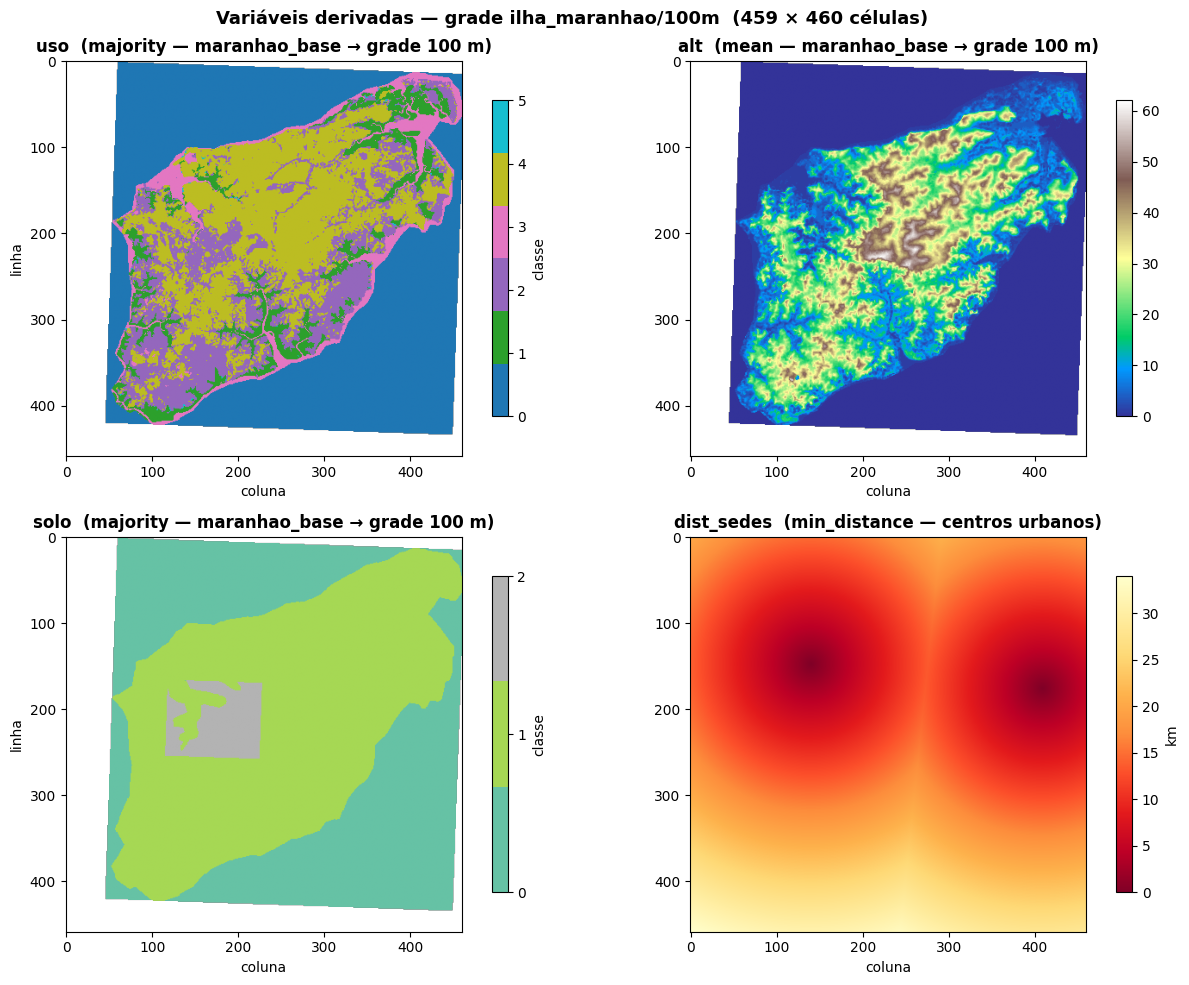

In [11]:
cmap_uso6  = plt.get_cmap("tab10", 6)
cmap_solo3 = plt.get_cmap("Set2",  3)

fig, axes = plt.subplots(2, 2, figsize=(13, 10))

# ── uso ───────────────────────────────────────────────────────────────────────
ax = axes[0, 0]
im = ax.imshow(da_uso.values, cmap=cmap_uso6, vmin=0, vmax=5, origin="upper")
ax.set_title("uso  (majority — maranhao_base → grade 100 m)", fontweight="bold")
ax.set_xlabel("coluna"); ax.set_ylabel("linha")
plt.colorbar(im, ax=ax, ticks=range(6), shrink=0.8, label="classe")

# ── alt ───────────────────────────────────────────────────────────────────────
ax = axes[0, 1]
im = ax.imshow(da_alt.values, cmap="terrain", origin="upper")
ax.set_title("alt  (mean — maranhao_base → grade 100 m)", fontweight="bold")
ax.set_xlabel("coluna")
plt.colorbar(im, ax=ax, shrink=0.8)

# ── solo ──────────────────────────────────────────────────────────────────────
ax = axes[1, 0]
im = ax.imshow(da_solo.values, cmap=cmap_solo3, vmin=0, vmax=2, origin="upper")
ax.set_title("solo  (majority — maranhao_base → grade 100 m)", fontweight="bold")
ax.set_xlabel("coluna"); ax.set_ylabel("linha")
plt.colorbar(im, ax=ax, ticks=[0, 1, 2], shrink=0.8, label="classe")

# ── dist_sedes ────────────────────────────────────────────────────────────────
ax = axes[1, 1]
im = ax.imshow(da_dist.values / 1000, cmap="YlOrRd_r", origin="upper")
ax.set_title("dist_sedes  (min_distance — centros urbanos)", fontweight="bold")
ax.set_xlabel("coluna")
plt.colorbar(im, ax=ax, shrink=0.8, label="km")

plt.suptitle(f"Variáveis derivadas — grade ilha_maranhao/100m  "
             f"({da_uso.shape[0]} × {da_uso.shape[1]} células)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


## Série temporal — acessar por ano

`cube.load("uso_mb")` devolve um `DataArray` com dimensão `time`.
Para acessar um ano específico, use `da.sel(time=ano)`.

No `RasterBackend`, o mesmo acesso é feito via `backend.get("uso_mb", time=ano)`.

> **Atenção**: os pixels com classe 0 (fundo / água fora da ilha) representam
> área sem dado de cobertura — o MapBiomas não define nodata neste arquivo,
> mas esses pixels deveriam ser mascarados em análises quantitativas.


DataArray temporal: dims=('time', 'y', 'x')  shape=(2, 459, 460)
Anos disponíveis  : [2010, 2022]


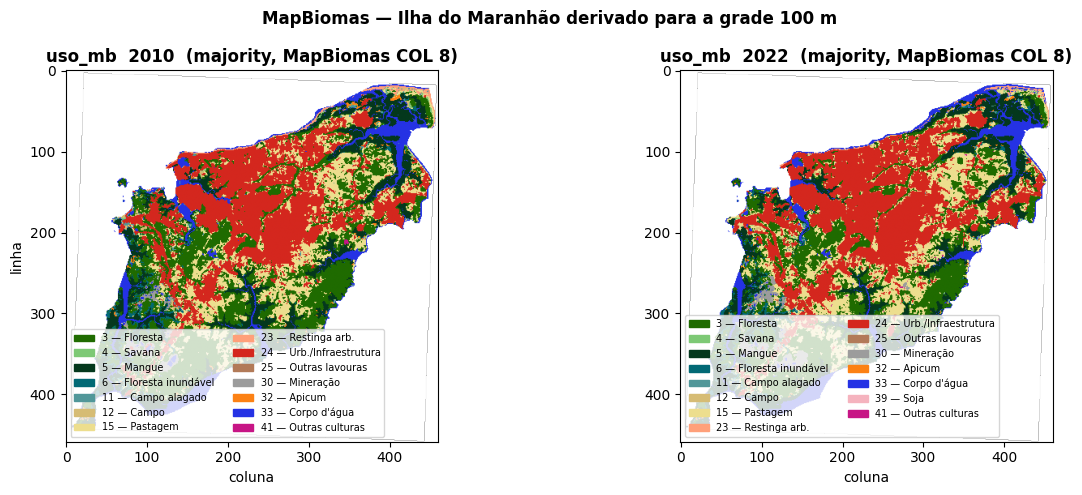


Área por classe (células de 100 m × 100 m = 1 ha cada):
  Classe  Nome                        2010 (ha)   2022 (ha)      Δ (ha)
  -----------------------------------------------------------------


  3      Floresta                       26,313      21,885      -4,428
  4      Savana                            525         387        -138
  5      Mangue                         14,992      15,400        +408
  6      Floresta inundável              1,995       1,944         -51
  11     Campo alagado                     618         322        -296
  12     Campo                             503         212        -291
  15     Pastagem                       15,221      16,716      +1,495
  23     Restinga arb.                     687         378        -309
  24     Urb./Infraestrutura            26,869      29,627      +2,758
  25     Outras lavouras                    81         239        +158
  30     Mineração                       1,105       2,009        +904
  32     Apicum                            586         323        -263
  33     Corpo d'água                    7,674       7,686         +12
  39     Soja                                0          12         +12
  41  

In [12]:
da_mb = cube.load("uso_mb", grid_id="ilha_maranhao/100m")
print(f"DataArray temporal: dims={da_mb.dims}  shape={da_mb.shape}")
print(f"Anos disponíveis  : {list(da_mb.coords['time'].values)}")

classes = sorted(MB_LEGEND)
cmap_mb = mcolors.ListedColormap([MB_LEGEND[c][1] for c in classes])
bounds_mb = [c - 0.5 for c in classes] + [classes[-1] + 0.5]
norm_mb   = mcolors.BoundaryNorm(bounds_mb, len(classes))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, year in zip(axes, [2010, 2022]):
    slice_arr = da_mb.sel(time=year).values
    ax.imshow(slice_arr, cmap=cmap_mb, norm=norm_mb, origin="upper")
    ax.set_title(f"uso_mb  {year}  (majority, MapBiomas COL 8)", fontweight="bold")
    ax.set_xlabel("coluna")
    present = {int(v) for v in slice_arr.flatten() if not np.isnan(v)}
    patches = [mpatches.Patch(color=MB_LEGEND[c][1],
                              label=f"{c} — {MB_LEGEND[c][0]}")
               for c in classes
               if c != 0 and c in present]
    ax.legend(handles=patches, fontsize=7, loc="lower left", ncol=2)
axes[0].set_ylabel("linha")

plt.suptitle("MapBiomas — Ilha do Maranhão derivado para a grade 100 m",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

# Comparar áreas por classe entre 2010 e 2022
print("\nÁrea por classe (células de 100 m × 100 m = 1 ha cada):")
arr10 = da_mb.sel(time=2010).values.flatten()
arr22 = da_mb.sel(time=2022).values.flatten()
print(f"  {'Classe':<5}  {'Nome':<25}  {'2010 (ha)':>10}  {'2022 (ha)':>10}  {'Δ (ha)':>10}")
print(f"  {'-'*65}")
# Exclude NaN from class list (border cells with no data)
cls10 = {int(c) for c in arr10 if not np.isnan(c)}
cls22 = {int(c) for c in arr22 if not np.isnan(c)}
all_cls = sorted(cls10 | cls22)
for c in all_cls:
    if c == 0: continue
    n10 = int((arr10 == c).sum())
    n22 = int((arr22 == c).sum())
    name = MB_LEGEND.get(c, ("?", "#000"))[0]
    print(f"  {c:<5}  {name:<25}  {n10:>10,}  {n22:>10,}  {n22-n10:>+10,}")


## Coordenadas de pureza

Operadores categóricos (`majority`, `percentage`) anexam ao `DataArray`
duas coordenadas auxiliares que descrevem a composição interna da célula.

* **`coverage_purity`** — fração de pixels de origem *sem nodata* na célula.
  Idealmente 1.0; valores menores indicam células parcialmente cobertas
  (borda do raster ou nodata na fonte).

* **`dominance_purity`** — fração ocupada pela classe vencedora dentre os
  pixels válidos. Valores baixos (< 0.5) indicam células heterogêneas onde
  a classe majoritária mal supera as outras — útil para mascaramento de
  incerteza.

Aqui, as células de borda do raster MapBiomas (classe 0 = fundo) contribuem
para reduzir a `dominance_purity` nas células costeiras.


Coordenadas de 'uso': ['band', 'dominance_purity', 'y', 'coverage_purity', 'x']



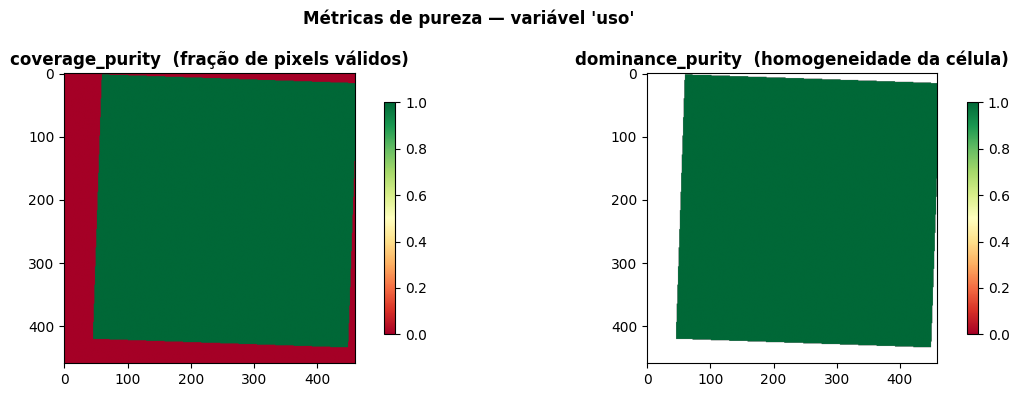

coverage_purity : min=0.000  mean=0.800  max=1.000
dominance_purity: min=1.000  mean=1.000  max=1.000
  (NaN nas células totalmente fora da extensão do raster — cobertura = 0)


In [13]:
# uso derivado de maranhao_base (estático)
da_uso_full = cube.load("uso", grid_id="ilha_maranhao/100m")
print("Coordenadas de 'uso':", list(da_uso_full.coords))
print()

cov = da_uso_full.coords["coverage_purity"].values
dom = da_uso_full.coords["dominance_purity"].values

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

im0 = axes[0].imshow(cov, cmap="RdYlGn", vmin=0, vmax=1, origin="upper")
axes[0].set_title("coverage_purity  (fração de pixels válidos)", fontweight="bold")
plt.colorbar(im0, ax=axes[0], shrink=0.8)

im1 = axes[1].imshow(dom, cmap="RdYlGn", vmin=0, vmax=1, origin="upper")
axes[1].set_title("dominance_purity  (homogeneidade da célula)", fontweight="bold")
plt.colorbar(im1, ax=axes[1], shrink=0.8)

plt.suptitle("Métricas de pureza — variável 'uso'", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

print(f"coverage_purity : min={np.nanmin(cov):.3f}  mean={np.nanmean(cov):.3f}  max={np.nanmax(cov):.3f}")
print(f"dominance_purity: min={np.nanmin(dom):.3f}  mean={np.nanmean(dom):.3f}  max={np.nanmax(dom):.3f}")
print(f"  (NaN nas células totalmente fora da extensão do raster — cobertura = 0)")


## O catálogo

`cube.search()` mostra todas as variáveis derivadas registradas.
O campo `times` diferencia variáveis estáticas (lista vazia) de temporais.


In [14]:
all_vars = cube.search(grid="ilha_maranhao/100m")
print(f"Variáveis catalogadas: {len(all_vars)}\n")
print(f"{'Nome':<14} {'Role':<12} {'dtype':<9} {'times':<14} spec_hash")
print("-" * 70)
for v in sorted(all_vars, key=lambda x: x.name):
    print(f"{v.name:<14} {v.role:<12} {v.dtype:<9} {str(v.times):<14} {v.spec_hash[:12]}…")


Variáveis catalogadas: 6

Nome           Role         dtype     times          spec_hash
----------------------------------------------------------------------
alt            driver       int16     []             9623659920d0…
dist_sedes     driver       float64   []             0d41d163094f…
solo           driver       float64   []             9623659920d0…
uso            driver       float64   []             9623659920d0…
uso_mb         land_use     float64   [2010]         8b82474911f2…
uso_mb         land_use     float64   [2022]         7e47ca91b354…


## `to_lucc_data` — interface com o modelo BR-MANGUE

`to_lucc_data()` carrega múltiplas variáveis de uma vez e devolve um
`RasterBackend` — a interface que o modelo `BrmangueRasterExecutor` usa
para ler os dados a cada passo de simulação.

Variables estáticas ficam como arrays 2D `(y, x)`.
Variables temporais (`uso_mb`) ficam como arrays 3D `(time, y, x)` e são
acessadas via `backend.get("uso_mb", time=2010)`.

O argumento `period=("2010", "2022")` filtra os slices temporais — útil
para limitar a janela de simulação.


In [15]:
# Carrega variáveis estáticas + série temporal com filtro de período
backend = cube.to_lucc_data(
    ["uso", "alt", "solo", "dist_sedes", "uso_mb"],
    grid_id = "ilha_maranhao/100m",
    period  = ("2010", "2022"),
)

print("RasterBackend pronto!")
print(f"  shape     : {backend.shape}")
print(f"  variáveis : {list(backend.arrays.keys())}")
print()

for name in backend.arrays:
    arr = backend.get(name)
    print(f"  {name:<14} shape={arr.shape}  "
          f"dtype={arr.dtype}  "
          f"temporal={backend.is_temporal(name)}")


RasterBackend pronto!
  shape     : (459, 460)
  variáveis : ['uso', 'alt', 'solo', 'dist_sedes', 'uso_mb']

  uso            shape=(459, 460)  dtype=float64  temporal=False
  alt            shape=(459, 460)  dtype=float64  temporal=False
  solo           shape=(459, 460)  dtype=float64  temporal=False
  dist_sedes     shape=(459, 460)  dtype=float64  temporal=False
  uso_mb         shape=(2, 459, 460)  dtype=float64  temporal=True


In [16]:
# Demonstrar acesso temporal — como um modelo CA leria passo a passo
print("Acesso temporal a uso_mb (como um modelo CA faria a cada passo):")
for year in [2010, 2022]:
    slice_2d = backend.get("uso_mb", time=year)
    classes, counts = np.unique(slice_2d[slice_2d > 0], return_counts=True)
    dom_cls = classes[np.argmax(counts)]
    dom_name = MB_LEGEND.get(int(dom_cls), ("?",))[0]
    print(f"  {year}: shape={slice_2d.shape}  "
          f"classe dominante={int(dom_cls)} ({dom_name})  "
          f"pixels não-nulos={int((slice_2d > 0).sum()):,}")


Acesso temporal a uso_mb (como um modelo CA faria a cada passo):
  2010: shape=(459, 460)  classe dominante=24 (Urb./Infraestrutura)  pixels não-nulos=97,207
  2022: shape=(459, 460)  classe dominante=24 (Urb./Infraestrutura)  pixels não-nulos=97,220


## Resumo

Neste notebook:

1. **Inspecionamos** os arquivos brutos em `data/raw/` — CRS, resolução e classes.
2. **Registramos** a grade `ilha_maranhao/100m` em BDC Albers via `register_local_grid()`.
3. **Registramos** 4 fontes: um raster multi-banda, 2 rasters MapBiomas temporais e
   uma camada vetorial de pontos.
4. **Derivamos** 5 variáveis:
   - `uso`, `alt`, `solo` em um único `SpatialDerivation` (3 bandas, 3 operadores).
   - `uso_mb` × 2 anos → série temporal com `time=[2010]` e `time=[2022]`.
   - `dist_sedes` via `min_distance` sobre vetor real (224 cidades, EPSG:5880→BDC Albers).
5. **Visualizamos** os arrays resultantes e as métricas de pureza.
6. **Consumimos** via `to_lucc_data()` — interface para o modelo BR-MANGUE.

### Próximos passos

- `examples/case_studies/maranhao/03_brmangue_simulate.py` — executa o
  `BrmangueRasterExecutor` sobre este backend.
- Para adicionar mais anos MapBiomas, repita o laço com os arquivos anuais.
- Para usar a grade nacional (`BR/5km`), substitua `grid_id` e ajuste o
  `register_simulation_grids()` do `utils/grids.py`.
